# Лабораторная работа 1
### "Классификация новостей"

Цель работы: создать НС, которая определяет категорию новости (спорт, IT, бизнес, преступления).

## 1. Установка библиотек

In [1]:
!pip install torch==2.3.0 torchtext==0.18.0

In [2]:
import os
os.environ["TORCHDYNAMO_DISABLE"] = "1"
os.environ["TORCH_COMPILE_DISABLE"] = "1"

## 2. Загрузка датасета

Загружаем CSV-файл с новостями. Файл должен содержать столбцы с текстом новости и её категорией. Я загрузила датасет себе на диск и сделала загрузку с него для удобства

In [3]:
import gdown

url = f"https://drive.google.com/uc?id=1Xn7ooFCZIKxfjwb83X-WOfnXEixQm1Hz"
output = "ag_news.csv"

gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1Xn7ooFCZIKxfjwb83X-WOfnXEixQm1Hz
To: /content/ag_news.csv
100%|██████████| 30.2M/30.2M [00:00<00:00, 43.2MB/s]


'ag_news.csv'

In [4]:
import pandas as pd

data = pd.read_csv('ag_news.csv', sep=';')
print(data.head())

   category                                            content
0        IT   webify helps insurance carriers stretch legac...
1  business   update 1 thursday #39 s commodities roundup ,...
2  business   california regulator is suing four insurers a...
3     crime   mexico fta paves way for asian trade agreemen...
4     sport   t amp t , costa rica through , angus eve scor...


## 3. Предобработка данных

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   category  120000 non-null  object
 1   content   120000 non-null  object
dtypes: object(2)
memory usage: 1.8+ MB


Нам очень повезло, в данных нет пропусков

In [6]:
TEXT_COL = 'content'
LABEL_COL = 'category'

Переводим категории в числовой формат

In [7]:
data[LABEL_COL] = data[LABEL_COL].astype('category')
print("Категории:", dict(enumerate(data[LABEL_COL].cat.categories)))
data[LABEL_COL] = data[LABEL_COL].cat.codes

Категории: {0: 'IT', 1: 'business', 2: 'crime', 3: 'sport'}


In [8]:
print(data[LABEL_COL].value_counts())

category
0    30000
1    30000
2    30000
3    30000
Name: count, dtype: int64


Опять сказочно повезло, нет дисбаланса классов еее

## 4. Разделение данных на тренировочные, валидационные и тестовые

In [9]:
from sklearn.model_selection import train_test_split

X = data[TEXT_COL]
y = data[LABEL_COL]

data_train, data_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# из оставшихся 80% отделяем валидацию (15% от всех данных = 18.75% от data_train)
data_train, data_val, y_train, y_val = train_test_split(
    data_train, y_train, test_size=0.1875, random_state=42  # 0.1875 * 0.8 = 0.15
)

print(f"Тренировочных примеров: {len(data_train)}")
print(f"Валидационных примеров: {len(data_val)}")
print(f"Тестовых примеров: {len(data_test)}")

Тренировочных примеров: 78000
Валидационных примеров: 18000
Тестовых примеров: 24000


## 5. Создание словаря (vocab)

Строим словарь по тренировочным данным, разбивая текст на слова (токены).

In [10]:
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
import torchtext
torchtext.disable_torchtext_deprecation_warning() # токенизатор ругался, там что-то устарело

# tokenizer разбивает строку на слова и приводит к нижнему регистру
tokenizer = get_tokenizer('basic_english')

def yield_tokens(texts):
    for text in texts:
        yield tokenizer(text) # yield возращает каждый раз tokenizer(text)

# Строим словарь только по тренировочным данным, тестовые мы не знаем, валидационные тоже
vocab = build_vocab_from_iterator(yield_tokens(data_train), specials=["<unk>"])
vocab.set_default_index(vocab["<unk>"])  # неизвестным словам присваивается индекс 0

print(f"Размер словаря: {len(vocab)}")

/usr/local/lib/python3.12/dist-packages/torchtext/data/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated

Размер словаря: 78225


Посмотим, нет ли сильного разброса по токенам в тесте, вале и трейне.

In [11]:
# Функция анализа покрытия. Анализирует, какой процент токенов известен словарю
def analyze_coverage(texts, vocab):
    total_tokens = 0
    known_tokens = 0
    unknown_tokens = 0
    unique_unknown = set()

    for text in texts:
        if pd.isna(text) or str(text).strip() == '':
            empty_texts += 1
            continue

        tokens = tokenizer(str(text))
        for token in tokens:
            total_tokens += 1
            if token in vocab:
                known_tokens += 1
            else:
                unknown_tokens += 1
                unique_unknown.add(token)

    known_percentage = (known_tokens / total_tokens) * 100 if total_tokens > 0 else 0
    unknown_percentage = (unknown_tokens / total_tokens) * 100 if total_tokens > 0 else 0

    return {
        'total_tokens': total_tokens,
        'known_tokens': known_tokens,
        'unknown_tokens': unknown_tokens,
        'known_percentage': known_percentage,
        'unknown_percentage': unknown_percentage,
        'unique_known': len(vocab),
        'unique_unknown': len(unique_unknown)
    }


test_stats = analyze_coverage(data_test, vocab)
print(f"Всего токенов в тесте: {test_stats['total_tokens']:,}")
print(f"Известных токенов: {test_stats['known_tokens']:,} ({test_stats['known_percentage']:.2f}%)")
print(f"Неизвестных токенов: {test_stats['unknown_tokens']:,} ({test_stats['unknown_percentage']:.2f}%)")
print(f"Размер словаря (уникальных слов в тренировке): {test_stats['unique_known']:,}")
print(f"Уникальных неизвестных слов в тесте: {test_stats['unique_unknown']:,}")

Всего токенов в тесте: 1,063,671
Известных токенов: 1,051,592 (98.86%)
Неизвестных токенов: 12,079 (1.14%)
Размер словаря (уникальных слов в тренировке): 78,225
Уникальных неизвестных слов в тесте: 10,508


У нас всё отлично, 98.86%

## 6. Класс Dataset и загрузчики данных

In [12]:
import torch
from torch.utils.data import Dataset, DataLoader

class NewsDataset(Dataset):
    def __init__(self, data_text, labels):
        self.data = data_text.reset_index(drop=True) # сбрасывает индексы и создает новую нумерацию строк с 0
        self.y = labels.reset_index(drop=True)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Разбиваем текст на слова (tokenizer вместо list)
        text = vocab(tokenizer(self.data[idx]))
        return torch.tensor(text, dtype=torch.int64), torch.tensor(self.y[idx], dtype=torch.int64)

In [13]:
def collate_batch(batch):
    """Собирает батч: выравнивает тексты разной длины через EmbeddingBag offsets."""
    label_list, text_list, offsets = [], [], [0]
    for (_text, _label) in batch:
        label_list.append(_label)
        processed_text = _text.clone().detach()
        text_list.append(processed_text)
        offsets.append(processed_text.size(0))
    label_list = torch.tensor(label_list, dtype=torch.int64)
    offsets = torch.tensor(offsets[:-1]).cumsum(dim=0)
    text_list = torch.cat(text_list)
    return label_list, text_list, offsets

In [14]:
trainset = NewsDataset(data_train, y_train)
valset = NewsDataset(data_val, y_val)
testset  = NewsDataset(data_test,  y_test)

trainloader = DataLoader(trainset, batch_size=16, shuffle=True,  collate_fn=collate_batch)
valloader = DataLoader(valset, batch_size=16, shuffle=False, collate_fn=collate_batch)
testloader  = DataLoader(testset,  batch_size=16, shuffle=False, collate_fn=collate_batch)

## 7. Архитектура нейросети

---

Использую ансамбль, ниже архитектуры трёх моделей



In [21]:
from torch import nn
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# EmbeddingBag (лёгкая, быстрая)
class TextClassifierEmbBag(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, dropout=0.3):
        super().__init__()
        self.embedding = nn.EmbeddingBag(vocab_size, embed_dim)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, text, offsets):
        embedded = self.embedding(text, offsets)
        return self.classifier(embedded)

# Embedding + LSTM
class TextClassifierLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True,
                            bidirectional=True, num_layers=1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, num_classes)
        )

    def forward(self, text, offsets):
        # text — конкатенированные токены; восстанавливаем батч из offsets
        batch_size = offsets.size(0)
        max_len = max(
            (offsets[i+1] - offsets[i]).item() if i+1 < batch_size else (text.size(0) - offsets[i]).item()
            for i in range(batch_size)
        )
        # Создаём padded-тензор
        padded = torch.zeros(batch_size, max_len, dtype=torch.long, device=text.device)
        lengths = []
        for i in range(batch_size):
            start = offsets[i].item()
            end = offsets[i+1].item() if i+1 < batch_size else text.size(0)
            length = end - start
            padded[i, :length] = text[start:end]
            lengths.append(max(length, 1))

        embedded = self.embedding(padded)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths, batch_first=True, enforce_sorted=False
        )
        _, (hidden, _) = self.lstm(packed)
        # hidden: [2, batch, hidden_dim] (bidirectional) → concat
        out = torch.cat([hidden[0], hidden[1]], dim=1)
        return self.classifier(out)

# Embedding + Conv1d (TextCNN)
class TextClassifierCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes,
                 num_filters=128, kernel_sizes=(3, 4, 5), dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, text, offsets):
        batch_size = offsets.size(0)
        max_len = max(
            (offsets[i+1] - offsets[i]).item() if i+1 < batch_size else (text.size(0) - offsets[i]).item()
            for i in range(batch_size)
        )
        max_len = max(max_len, max(3, 4, 5))  # минимальная длина для свёрток

        padded = torch.zeros(batch_size, max_len, dtype=torch.long, device=text.device)
        for i in range(batch_size):
            start = offsets[i].item()
            end = offsets[i+1].item() if i+1 < batch_size else text.size(0)
            length = end - start
            padded[i, :length] = text[start:end]

        # [batch, max_len, embed] → [batch, embed, max_len]
        embedded = self.embedding(padded).permute(0, 2, 1)
        pooled = [torch.relu(conv(embedded)).max(dim=2).values for conv in self.convs]
        out = torch.cat(pooled, dim=1)
        return self.classifier(self.dropout(out))

## 8. Обучение нейросети

график для лосса и аккураси

In [16]:
# @title
import matplotlib.pyplot as plt
from IPython.display import clear_output

def plot_history(history, epoch):
    """
    Строит графики loss и accuracy на текущий момент обучения,
    стирая предыдущие графики

    Args:
        history: dict с ключами 'train_loss', 'val_loss', 'train_acc', 'val_acc'
        epoch: текущий номер эпохи (для заголовка)
    """
    # Очищаем вывод предыдущего графика
    clear_output(wait=True)

    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # График потерь (Loss)
    ax1.plot(epochs, history['train_loss'], label='Train Loss', marker='o', color='blue', linewidth=2)
    ax1.plot(epochs, history['val_loss'], label='Validation Loss', marker='s', color='red', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title(f'Loss over epochs (Epoch {epoch})', fontsize=14)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # График точности (Accuracy)
    ax2.plot(epochs, history['train_acc'], label='Train Accuracy', marker='o', color='blue', linewidth=2)
    ax2.plot(epochs, history['val_acc'], label='Validation Accuracy', marker='s', color='red', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title(f'Accuracy over epochs (Epoch {epoch})', fontsize=14)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

итоговый график

In [17]:
# @title
import matplotlib.pyplot as plt
from IPython.display import clear_output
import copy

def plot_final(history, model_name, best_epoch):
    """
    Итоговый статичный график для одной модели с отмеченной лучшей эпохой.
    """
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} — итог обучения', fontsize=15)

    # Loss
    ax1.plot(epochs, history['train_loss'], label='Train Loss', marker='o', color='steelblue', linewidth=2)
    ax1.plot(epochs, history['val_loss'],   label='Val Loss',   marker='s', color='tomato',   linewidth=2)
    ax1.axvline(best_epoch, color='green', linestyle='--', linewidth=1.5, label=f'Выбранная эпоха {best_epoch}')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(epochs, history['train_acc'], label='Train Acc', marker='o', color='steelblue', linewidth=2)
    ax2.plot(epochs, history['val_acc'],   label='Val Acc',   marker='s', color='tomato',   linewidth=2)
    ax2.axvline(best_epoch, color='green', linestyle='--', linewidth=1.5, label=f'Выбранная эпоха {best_epoch}')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f"  Лучшая эпоха: {best_epoch} | Val Acc: {history['val_acc'][best_epoch-1]:.4f}")

функция для обучения

In [18]:
# @title
def train_model(model, model_name, trainloader, valloader,
                num_epochs=10, lr=1e-3, patience=3):
    """
    Обучает модель, рисует live-графики через plot_history,
    затем строит итоговый график с выбранной эпохой.

    Возвращает модель с весами лучшей эпохи и историю обучения.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.to(device)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_epoch = 1
    best_weights = copy.deepcopy(model.state_dict())
    no_improve = 0

    for epoch in range(1, num_epochs + 1):

        # Train
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for labels, inputs, offsets in trainloader:
            labels, inputs, offsets = labels.to(device), inputs.to(device), offsets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs, offsets)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * labels.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        train_loss = total_loss / total
        train_acc  = correct / total

        # ---- Validation ----
        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for labels, inputs, offsets in valloader:
                labels, inputs, offsets = labels.to(device), inputs.to(device), offsets.to(device)
                outputs = model(inputs, offsets)
                loss = criterion(outputs, labels)
                total_loss += loss.item() * labels.size(0)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += labels.size(0)
        val_loss = total_loss / total
        val_acc  = correct / total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # Сохраняем лучшую эпоху
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_weights = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        # Live-график (использует уже готовую функцию plot_history)
        plot_history(history, epoch)
        print(f"[{model_name}] Epoch {epoch}/{num_epochs} | "
              f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
              f"train_acc={train_acc:.4f} val_acc={val_acc:.4f}")

        if no_improve >= patience:
            print(f"  Early stopping на эпохе {epoch} (лучшая: {best_epoch})")
            break

    # Восстанавливаем лучшие веса
    model.load_state_dict(best_weights)

    # Итоговый статичный график с отмеченной эпохой
    plot_final(history, model_name, best_epoch)

    return model, history

Создаём и обучаем каждую модель

In [19]:
VOCAB_SIZE  = len(vocab)
NUM_CLASSES = 4

Модель 1 — EmbeddingBag

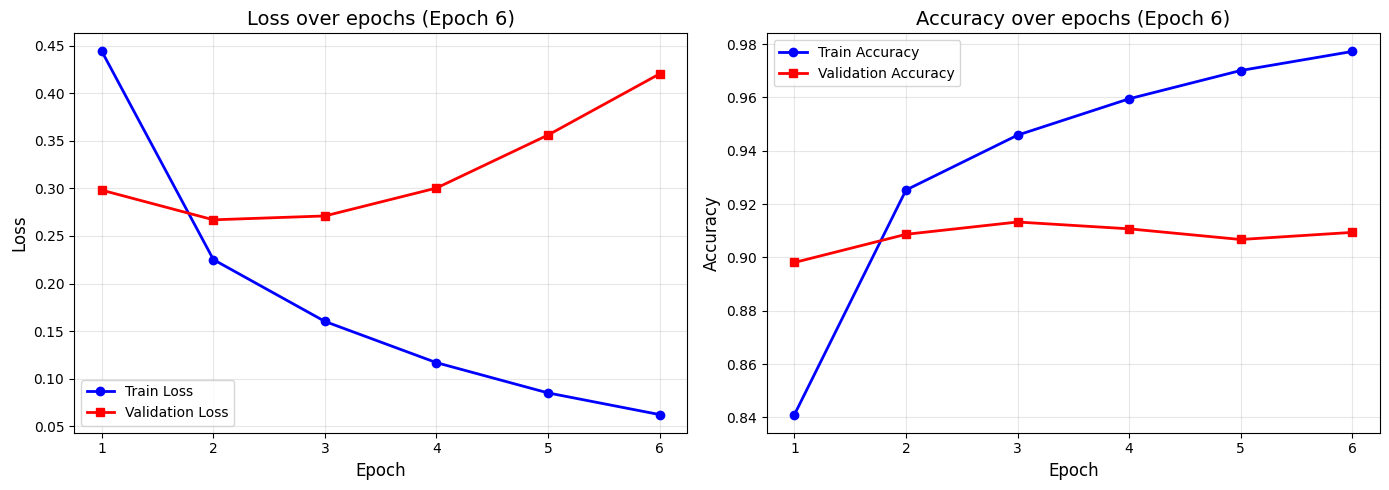

[EmbeddingBag] Epoch 6/15 | train_loss=0.0622 val_loss=0.4204 | train_acc=0.9772 val_acc=0.9094
  Early stopping на эпохе 6 (лучшая: 3)


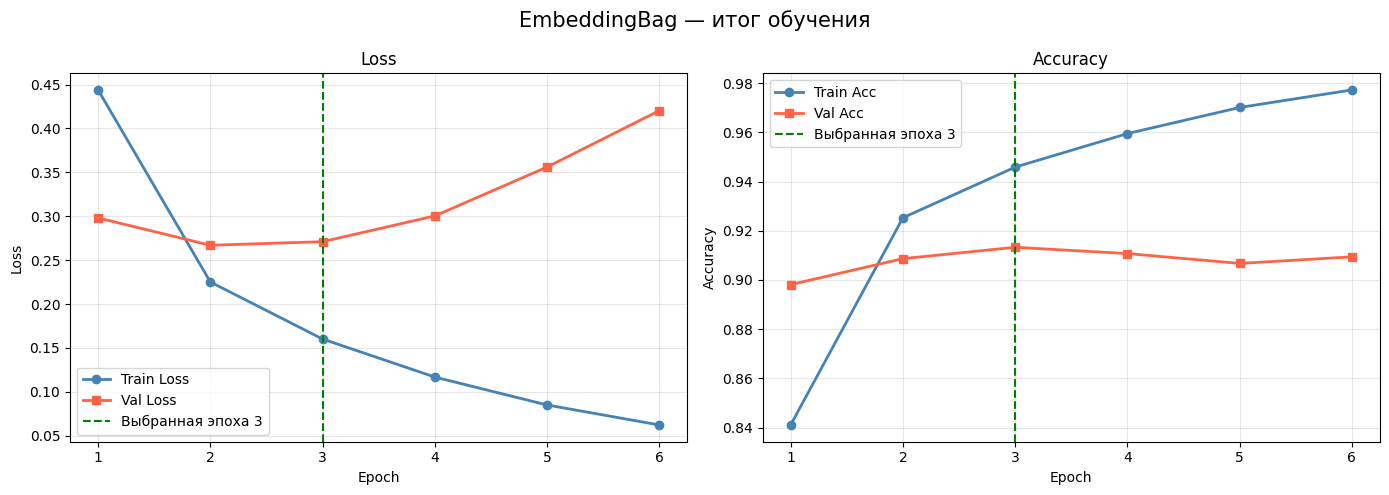

  Лучшая эпоха: 3 | Val Acc: 0.9133


In [22]:
model1 = TextClassifierEmbBag(vocab_size=VOCAB_SIZE, embed_dim=128, num_classes=NUM_CLASSES)
model1, history1 = train_model(model1, "EmbeddingBag", trainloader, valloader,
                                num_epochs=15, lr=1e-3, patience=3)

Модель 2 — LSTM

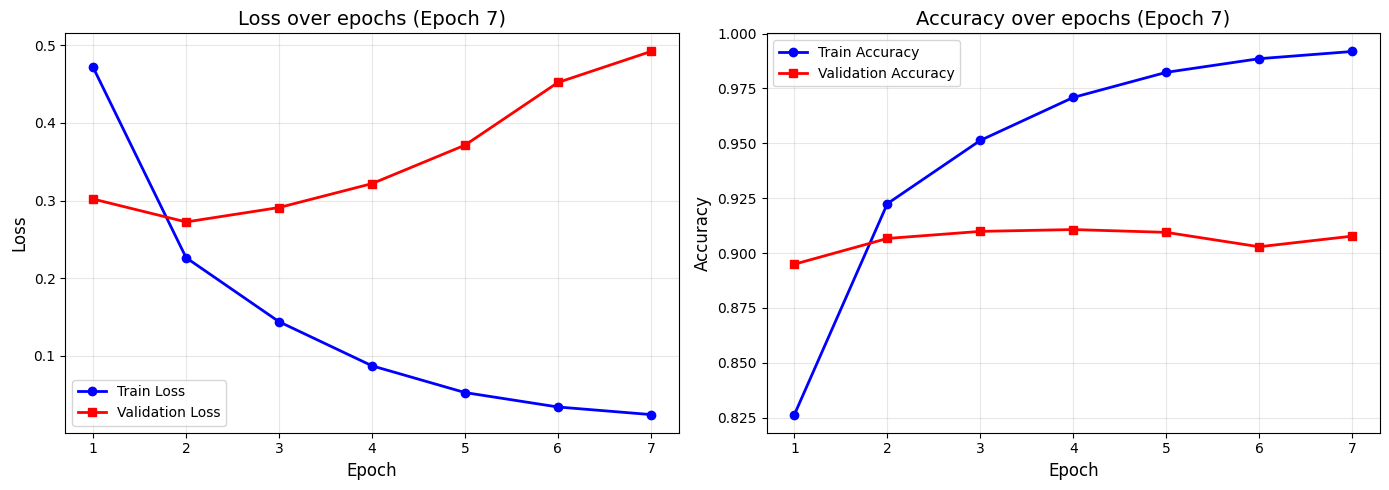

[LSTM] Epoch 7/15 | train_loss=0.0246 val_loss=0.4920 | train_acc=0.9918 val_acc=0.9077
  Early stopping на эпохе 7 (лучшая: 4)


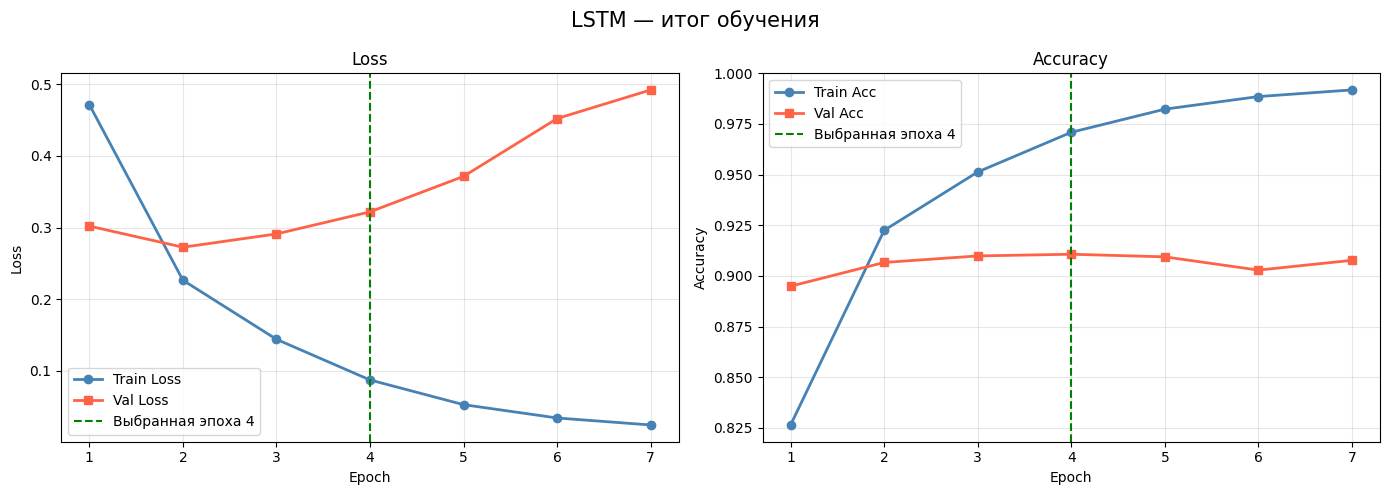

  Лучшая эпоха: 4 | Val Acc: 0.9107


In [23]:
model2 = TextClassifierLSTM(vocab_size=VOCAB_SIZE, embed_dim=128, hidden_dim=128, num_classes=NUM_CLASSES)
model2, history2 = train_model(model2, "LSTM", trainloader, valloader,
                                num_epochs=15, lr=1e-3, patience=3)

Модель 3 — CNN

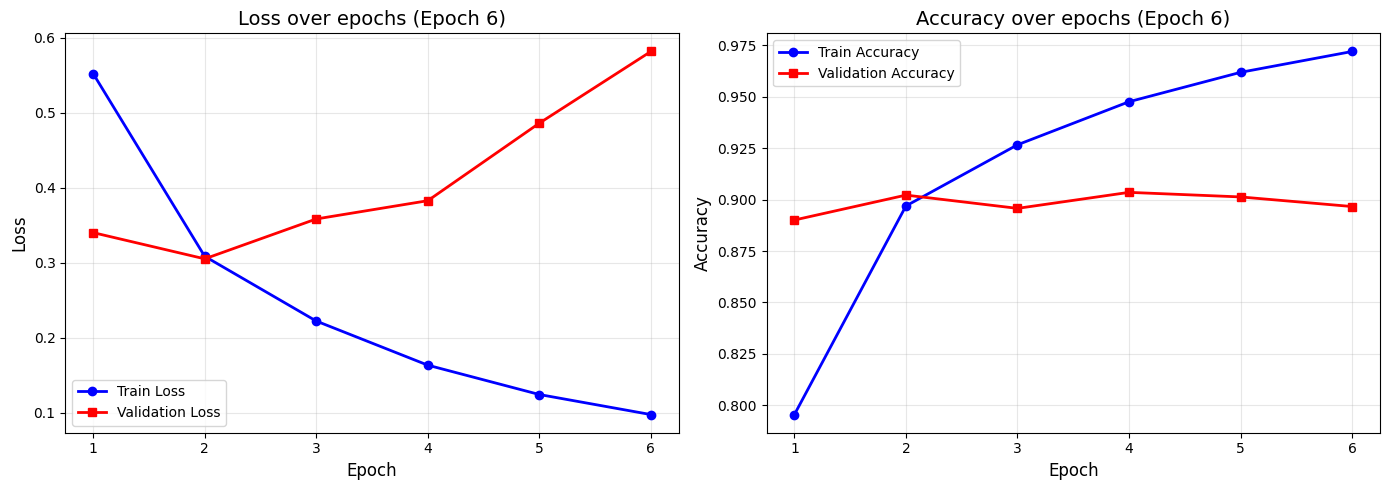

[TextCNN] Epoch 6/15 | train_loss=0.0978 val_loss=0.5818 | train_acc=0.9719 val_acc=0.8966
  Early stopping на эпохе 6 (лучшая: 4)


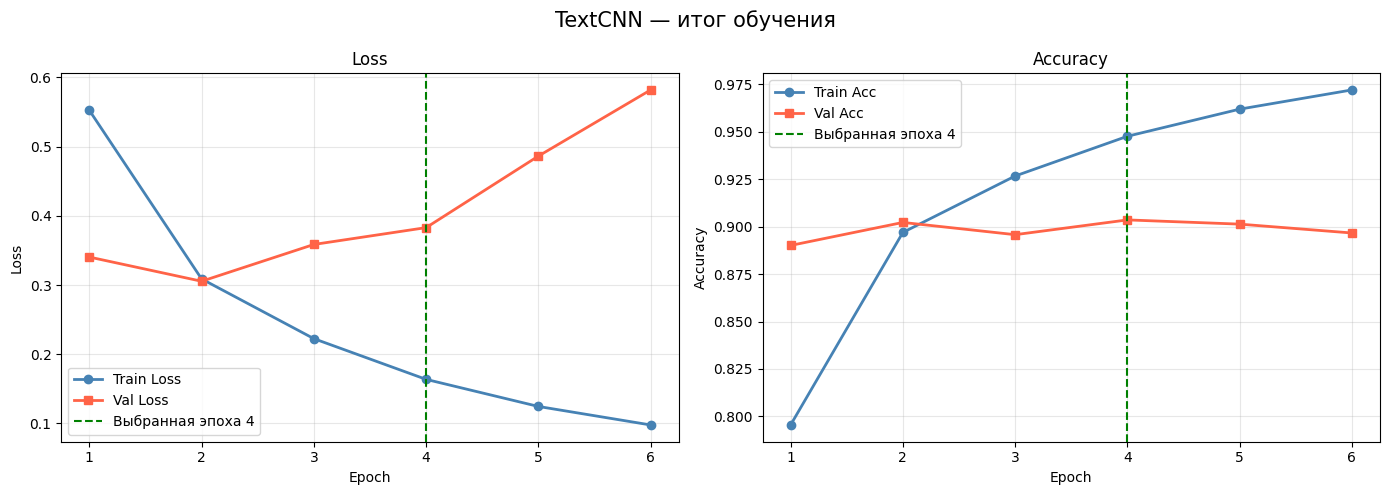

  Лучшая эпоха: 4 | Val Acc: 0.9035


In [25]:
model3 = TextClassifierCNN(vocab_size=VOCAB_SIZE, embed_dim=128, num_classes=NUM_CLASSES)
model3, history3 = train_model(model3, "TextCNN", trainloader, valloader,
                               num_epochs=15, lr=1e-3, patience=2)

# 9. Ансамбль — усреднение вероятностей (Soft Voting)

In [26]:
import numpy as np
from sklearn.metrics import classification_report

def ensemble_predict(models, loader, device):
    """
    Мягкое голосование: усредняем softmax-вероятности всех моделей.
    Возвращает (предсказания, истинные метки).
    """
    for m in models:
        m.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for labels, inputs, offsets in loader:
            labels  = labels.to(device)
            inputs  = inputs.to(device)
            offsets = offsets.to(device)

            # Суммируем вероятности
            probs = sum(
                torch.softmax(m(inputs, offsets), dim=1) for m in models
            ) / len(models)

            preds = probs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

## 10. Тестирование нейросети

In [27]:
ensemble_models = [model1, model2, model3]
preds, labels = ensemble_predict(ensemble_models, testloader, device)

accuracy = (preds == labels).mean()
print(f"Ensemble Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")
print("Classification Report (Ensemble):")
print(classification_report(labels, preds,
                             target_names=['IT', 'business', 'crime', 'sport']))

Ensemble Accuracy: 0.9297 (92.97%)

Classification Report (Ensemble):
              precision    recall  f1-score   support

          IT       0.90      0.91      0.91      6038
    business       0.91      0.90      0.90      6064
       crime       0.94      0.92      0.93      5962
       sport       0.97      0.99      0.98      5936

    accuracy                           0.93     24000
   macro avg       0.93      0.93      0.93     24000
weighted avg       0.93      0.93      0.93     24000



*   Precision: из предсказанных как класс X — сколько реально X
*   Recall: из реальных X — сколько модель нашла
*   F1-score: среднее гармоническое между precision и recall

Сравнительный график — Val Accuracy всех моделей

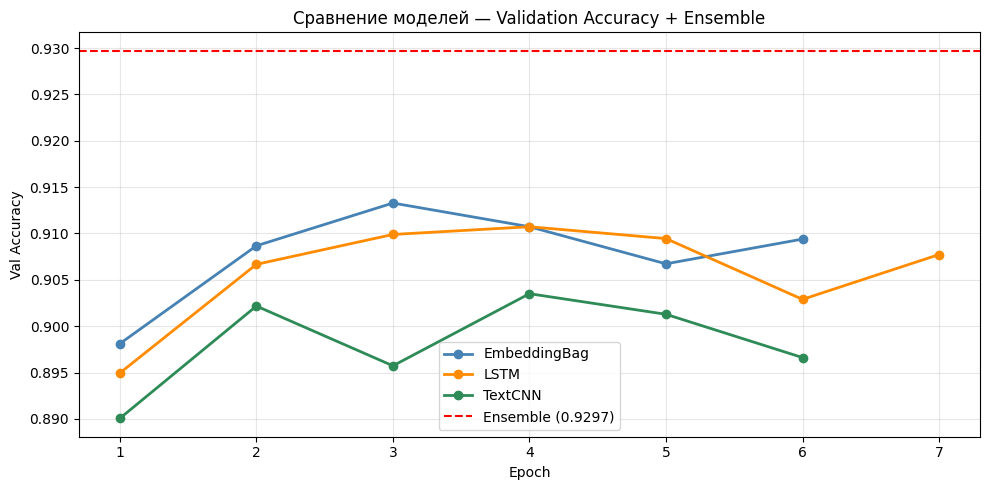

In [28]:
plt.figure(figsize=(10, 5))
for history, name, color in [
    (history1, 'EmbeddingBag', 'steelblue'),
    (history2, 'LSTM',         'darkorange'),
    (history3, 'TextCNN',      'seagreen'),
]:
    epochs = range(1, len(history['val_acc']) + 1)
    plt.plot(epochs, history['val_acc'], marker='o', label=name, color=color, linewidth=2)

plt.axhline(accuracy, color='red', linestyle='--', linewidth=1.5, label=f'Ensemble ({accuracy:.4f})')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy')
plt.title('Сравнение моделей — Validation Accuracy + Ensemble')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Проверка на отдельном примере

In [33]:
# Словарь категорий (восстанавливаем из исходных данных)
original_data = pd.read_csv('ag_news.csv', sep=';').dropna(subset=[TEXT_COL, LABEL_COL])
categories = dict(enumerate(original_data[LABEL_COL].astype('category').cat.categories))

def predict(text, models=None):
    """Предсказание через ансамбль (soft voting) или одну модель."""
    if models is None:
        models = ensemble_models  # по умолчанию — ансамбль

    tokens = torch.tensor(vocab(tokenizer(text)), dtype=torch.int64, device=device)
    offsets = torch.tensor([0], device=device)

    for m in models:
        m.eval()

    with torch.no_grad():
        probs = sum(
            torch.softmax(m(tokens, offsets), dim=1) for m in models
        ) / len(models)

    pred = probs.argmax(dim=1)
    return categories[pred.item()]


sample_text = "The team scored three goals in the championship match"
print(f"Текст: {sample_text}")
print(f"Предсказанная категория (ансамбль): {predict(sample_text)}")

# Можно также предсказать отдельной моделью:
# print(predict(sample_text, models=[model1]))

Текст: The team scored three goals in the championship match
Предсказанная категория (ансамбль): sport
